# ITCS 6169/8169 — Computer Vision
## Assignment 1: The CNN Challenge
**Due: September 25, 2026 at 11:59 PM EDT**

---

In this assignment, you will build and train a convolutional neural network (CNN) for **16-class scene recognition** using a small dataset of **2,400 training images**.

This notebook is intentionally only a **starter baseline**. It provides a clean training pipeline and a deliberately simple CNN. Your task is to improve the system through informed decisions about architecture, optimization, augmentation, regularization, model selection, and training strategy.

### 2026 workflow: AI is your pair programmer
Use of an AI coding assistant (e.g., ChatGPT, Codex, GitHub Copilot, Claude Code, Gemini, Cursor) is **required**. You may use AI to help implement, debug, refactor, explain, or suggest experiments. However, **you are responsible for the scientific decisions and for verifying all generated code**.

Your final GitHub repository must include an `AI_USAGE.md` file describing representative AI-assisted tasks, at least one incorrect/ineffective AI suggestion, how you verified or corrected it, and one important decision that you made yourself.

### Important model restriction
The primary classifier for Assignment 1 must be a **CNN**. Do **not** use CLIP, DINO/DINOv2, VLM APIs, Vision Transformers as the primary model, or other foundation-model embeddings for your main submission. Pretrained CNNs are allowed if clearly documented.

### Google Colab
Google Colab is recommended, but not required. If using Colab, enable a GPU through **Runtime → Change runtime type → GPU**. You may also use the Educational Cluster or another resource for which you have authorized access.

In [20]:
# Core imports
from pathlib import Path
import random
import time
import copy

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Set your working directory

Download the assignment dataset from the link provided in the assignment handout and organize it so that the notebook can find:

```text
data/
  train/
    class_1/
    ...
  test/
    class_1/
    ...
```

If you use Google Drive, change `PROJECT_ROOT` below to your assignment folder. **Do not hard-code a TA/instructor solution path.**

In [21]:
# CHANGE THIS PATH to your own assignment directory.
# Example for Colab + Google Drive:
# PROJECT_ROOT = Path('/content/gdrive/MyDrive/ITCS_6169_8169/assignment1')

PROJECT_ROOT = Path(r'C:\Users\abhin\Code\ComputerVision')
DATA_ROOT = PROJECT_ROOT / 'data'
TRAIN_ROOT = DATA_ROOT / 'train'
TEST_ROOT = DATA_ROOT / 'test'

print('Project root:', PROJECT_ROOT.resolve())
print('Training data:', TRAIN_ROOT)
print('Testing data:', TEST_ROOT)

Project root: C:\Users\abhin\Code\ComputerVision
Training data: C:\Users\abhin\Code\ComputerVision\data\train
Testing data: C:\Users\abhin\Code\ComputerVision\data\test


## 2. Reproducibility and device

A fixed seed makes the starter result easier to reproduce. Exact GPU reproducibility is not always guaranteed across hardware/software versions, so report your environment and seed in the final repository.

In [22]:
SEED = 0

def set_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_random_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 3. Loading and preprocessing the data

The starter baseline converts images to grayscale and resizes them to $64\times64$. This is **not necessarily a good final choice**. You should decide whether color, resolution, normalization, and augmentation should be changed.

We split the provided training data into **training and validation sets**. Use the validation set for architecture/hyperparameter decisions. **Do not repeatedly tune on the test set.** The test set should be used for the final evaluation of a selected model.

In [23]:
IMG_SIZE = 64
BATCH_SIZE = 64
VAL_FRACTION = 0.20

# Deliberately simple preprocessing for the starter baseline.
# TODO: improve this as part of your experiments.
baseline_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

full_train_dataset = datasets.ImageFolder(TRAIN_ROOT, transform=baseline_transform)
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=baseline_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')
print(f'Total training images: {len(full_train_dataset)}')
print(f'Test images: {len(test_dataset)}')

val_size = int(round(len(full_train_dataset) * VAL_FRACTION))
train_size = len(full_train_dataset) - val_size
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size], generator=generator
)

# num_workers=0 required on Windows inside a notebook (multiprocessing limitation)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=torch.cuda.is_available())

print(f'Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}')

Classes (16): ['Bedroom', 'Coast', 'Flower', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Total training images: 2400
Test images: 400
Train: 1920 | Validation: 480 | Test: 400


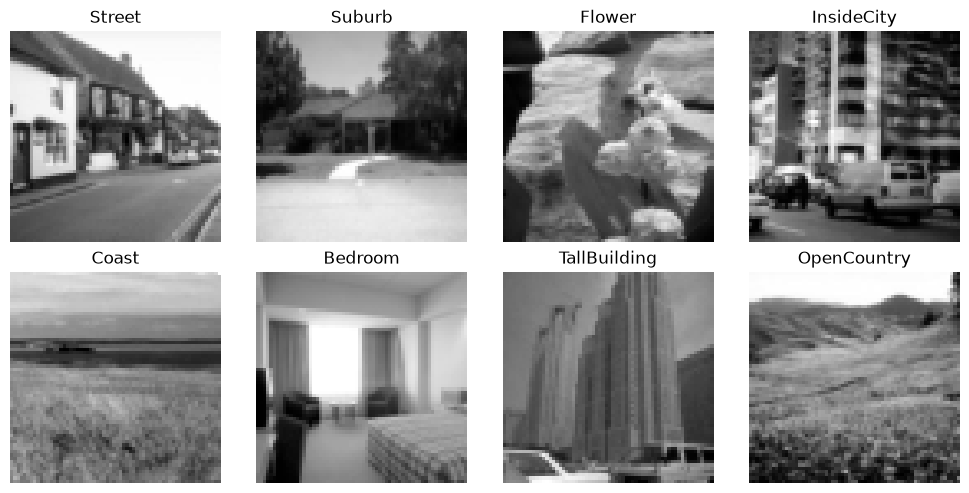

In [24]:
# Visualize a few training examples
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, image, label in zip(axes.flat, images[:8], labels[:8]):
    image = image * 0.5 + 0.5  # unnormalize
    ax.imshow(image.squeeze(0), cmap='gray')
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Training a CNN from scratch

Gone are the days when hand-designed features were the default solution. We will start with end-to-end learning and train a CNN directly for 16-way classification.

The architecture below is deliberately weak and simple. **Do not treat it as a recommended architecture.** It exists only to verify that the pipeline works and to give you a baseline to beat.

In [25]:
class TNet(nn.Module):
    """A deliberately small CNN starter baseline."""
    def __init__(self, num_classes=16):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=4, stride=4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 15 * 15, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = TNet(num_classes=num_classes)
print(model)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

TNet(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3600, out_features=16, bias=True)
  )
)
Trainable parameters: 57,776


## 5. Training and evaluation utilities

The training loop below selects the checkpoint with the **best validation accuracy**. This is a much better experimental practice than evaluating the test set after every epoch.

You are welcome to rewrite this code. For example, you may add a scheduler, mixed precision, early stopping, checkpointing, experiment tracking, or richer metrics. If AI helps you implement such changes, verify the implementation and document representative usage in `AI_USAGE.md`.

In [26]:
@torch.inference_mode()
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer, epochs=20, device=device, scheduler=None):
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    start = time.time()

    epoch_bar = tqdm(range(1, epochs + 1), desc='Epochs', unit='epoch')
    for epoch in epoch_bar:
        model.train()
        total_loss = 0.0
        total_seen = 0

        batch_bar = tqdm(train_loader, desc=f'  Epoch {epoch:02d}', leave=False, unit='batch')
        for images, labels in batch_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            total_seen += labels.size(0)
            batch_bar.set_postfix(loss=f'{loss.item():.4f}')

        train_loss = total_loss / total_seen
        val_loss, val_acc = evaluate(model, val_loader, device)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        if scheduler is not None:
            scheduler.step()

        epoch_bar.set_postfix(train_loss=f'{train_loss:.4f}', val_loss=f'{val_loss:.4f}', val_acc=f'{val_acc:.4f}')

    model.load_state_dict(best_state)
    elapsed = time.time() - start
    print(f'Training complete in {elapsed:.1f}s | Best val accuracy: {best_val_acc:.4f}')
    return model, history

In [27]:
def plot_history(history, label='Experiment', save_path=None):
    """Plot train/val loss and val accuracy. Call after every experiment."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(label, fontsize=13)

    ax1.plot(history['train_loss'], label='Train loss')
    ax1.plot(history['val_loss'], label='Val loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history['val_acc'], label='Val accuracy', color='green')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1)
    ax2.legend()

    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f'Saved to {save_path}')
    plt.show()
    best_val = max(history['val_acc'])
    print(f'Best val accuracy: {best_val:.4f} ({best_val*100:.1f}%)')

In [28]:
@torch.inference_mode()
def per_class_accuracy(model, loader, class_names, device):
    """Print sorted per-class accuracy with a visual bar. Call after plot_history."""
    model.eval()
    correct = torch.zeros(len(class_names))
    total = torch.zeros(len(class_names))

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        preds = model(images).argmax(dim=1).cpu()
        for pred, label in zip(preds, labels):
            total[label] += 1
            if pred == label:
                correct[label] += 1

    accs = (correct / total.clamp(min=1)).numpy()
    print(f"\nPer-class accuracy (val set):")
    print(f"{'Class':<22} {'Acc':>6}  Bar")
    print("-" * 52)
    for name, acc in sorted(zip(class_names, accs), key=lambda x: x[1]):
        bar = '█' * int(acc * 20)
        print(f"{name:<22} {acc:>5.1%}  {bar}")
    print(f"\nMean: {accs.mean():.1%}  |  Min: {accs.min():.1%}  |  Max: {accs.max():.1%}")
    return accs

In [ ]:
# Train the deliberately simple baseline.
set_random_seed(SEED)
model = TNet(num_classes=num_classes)
optimizer = optim.Adam(model.parameters(), lr=0.002)

model, history = train_model(
    model, train_loader, val_loader, optimizer, epochs=20, device=device
)

In [ ]:
plot_history(history, label='Experiment 0: Baseline TNet', save_path='plots/exp0_baseline.png')

---

## Experiment 1: ResNet18 Feature Extraction (Frozen Backbone)

**Hypothesis:** Pretrained ImageNet features redirected to 16 classes via a new head should substantially outperform TNet, establishing how much transfer learning alone is worth before any fine-tuning.

**Key changes from baseline:**
- Model: ResNet18 pretrained on ImageNet-1K, all conv layers frozen
- Only the final `fc` layer (512 → 16) is trained
- Input: RGB 224×224 with ImageNet normalization (pulled directly from weight metadata)

In [29]:
from torchvision.models import resnet18, ResNet18_Weights

# --- Standalone setup (skip if baseline cells already ran) ---
# Recomputes shared variables so this experiment can run without the baseline training cell.
# Still requires: imports cell, paths cell, seed/device cell, and utility-function cells.
BATCH_SIZE   = 64
VAL_FRACTION = 0.20

_probe = datasets.ImageFolder(TRAIN_ROOT)
class_names = _probe.classes
num_classes = len(class_names)
val_size   = int(round(len(_probe) * VAL_FRACTION))
train_size = len(_probe) - val_size
del _probe
print(f"Classes ({num_classes}): {class_names}")
print(f"Train: {train_size} | Val: {val_size}")
# --- End standalone setup ---

weights = ResNet18_Weights.DEFAULT
print(f"\nWeights: {weights}  |  Pretrained on: ImageNet-1K")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

resnet_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

exp1_full         = datasets.ImageFolder(TRAIN_ROOT, transform=resnet_transform)
exp1_test_dataset = datasets.ImageFolder(TEST_ROOT,  transform=resnet_transform)

generator = torch.Generator().manual_seed(SEED)
exp1_train_ds, exp1_val_ds = random_split(exp1_full, [train_size, val_size], generator=generator)

exp1_train_loader = DataLoader(exp1_train_ds,     batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0, pin_memory=torch.cuda.is_available())
exp1_val_loader   = DataLoader(exp1_val_ds,       batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=0, pin_memory=torch.cuda.is_available())
exp1_test_loader  = DataLoader(exp1_test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=0, pin_memory=torch.cuda.is_available())

print(f"Test: {len(exp1_test_dataset)}")

Classes (16): ['Bedroom', 'Coast', 'Flower', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Train: 1920 | Val: 480

Weights: ResNet18_Weights.IMAGENET1K_V1  |  Pretrained on: ImageNet-1K
Test: 400


In [30]:
# Load pretrained ResNet18 and freeze entire backbone
resnet = resnet18(weights=weights)

for param in resnet.parameters():
    param.requires_grad = False

# Replace classification head — only this will be trained
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet.parameters())
print(f"Trainable: {trainable:,} / {total:,} parameters ({trainable/total*100:.2f}%)")
print(f"Head: {resnet.fc}")

Trainable: 8,208 / 11,184,720 parameters (0.07%)
Head: Linear(in_features=512, out_features=16, bias=True)


In [16]:
set_random_seed(SEED)
# Only pass head parameters to optimizer — backbone is frozen
optimizer_exp1 = optim.Adam(resnet.fc.parameters(), lr=1e-3)

resnet, history_exp1 = train_model(
    resnet, exp1_train_loader, exp1_val_loader, optimizer_exp1, epochs=20, device=device
)

Epochs:   0%|          | 0/20 [00:00<?, ?epoch/s]

  Epoch 01:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 02:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 03:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 04:   0%|          | 0/30 [00:00<?, ?batch/s]

...

  Epoch 17:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 18:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 19:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 20:   0%|          | 0/30 [00:00<?, ?batch/s]

Training complete in 173.1s | Best val accuracy: 0.9042


Saved to plots/exp1_resnet18_frozen.png


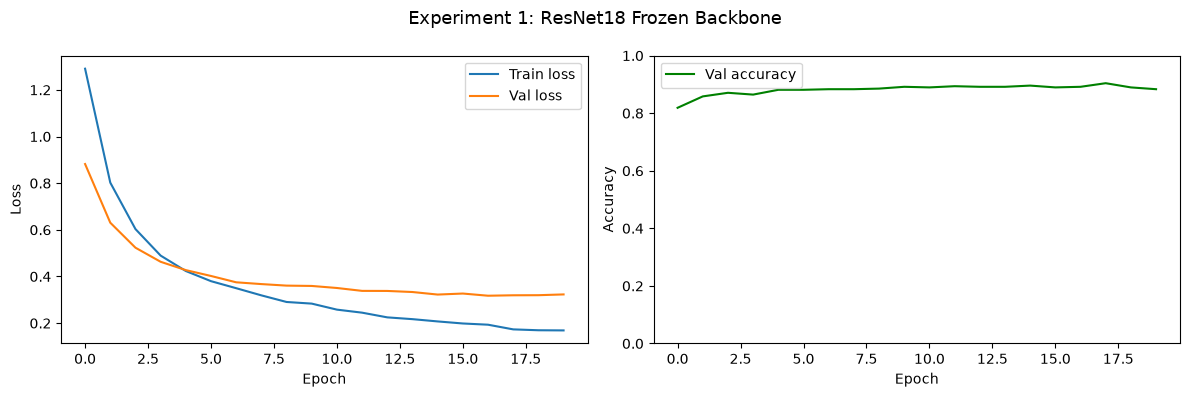

Best val accuracy: 0.9042 (90.4%)

Per-class accuracy (val set):
Class                     Acc  Bar
----------------------------------------------------
OpenCountry            75.0%  ███████████████
LivingRoom             76.9%  ███████████████
Bedroom                79.5%  ███████████████
Coast                  81.8%  ████████████████
InsideCity             83.3%  ████████████████
Kitchen                90.0%  ██████████████████
Store                  90.3%  ██████████████████
Mountain               92.9%  ██████████████████
Industrial             93.1%  ██████████████████
Office                 95.8%  ███████████████████
Highway                96.4%  ███████████████████
Street                 96.9%  ███████████████████
Suburb                 97.1%  ███████████████████
Flower                 100.0%  ████████████████████
Forest                 100.0%  ████████████████████
TallBuilding           100.0%  ████████████████████

Mean: 90.6%  |  Min: 75.0%  |  Max: 100.0%


array([0.7948718 , 0.8181818 , 1.        , 1.        , 0.96428573,
       0.9310345 , 0.8333333 , 0.9       , 0.7692308 , 0.9285714 ,
       0.9583333 , 0.75      , 0.9032258 , 0.96875   , 0.9705882 ,
       1.        ], dtype=float32)

In [17]:
plot_history(history_exp1, label='Experiment 1: ResNet18 Frozen Backbone', save_path='plots/exp1_resnet18_frozen.png')
per_class_accuracy(resnet, exp1_val_loader, class_names, device)

---

## Experiment 2: ResNet18 Frozen + Data Augmentation

**Hypothesis:** Augmenting the training set will improve generalization by exposing the classifier head to more varied views of each scene, pushing past the frozen backbone's ceiling without changing the model at all.

**Change from Exp 1:** Train transform adds `RandomHorizontalFlip`, `RandomResizedCrop`, and `ColorJitter`. Val and test transforms are unchanged — augmentation is training-only.

**What each augmentation does here:**
- `RandomHorizontalFlip` — scenes are horizontally symmetric; free invariance
- `RandomResizedCrop(224, scale=0.7–1.0)` — classifier sees partial/zoomed views; strongest generalization signal
- `ColorJitter(brightness, contrast, saturation)` — outdoor scenes vary widely in lighting conditions

**Requires:** Exp 1 setup cell to have run (provides `IMAGENET_MEAN`, `IMAGENET_STD`, `train_size`, `val_size`, `class_names`, `num_classes`)

In [31]:
# Augmented train transform — val/test use the same clean resnet_transform from Exp 1
aug_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

exp2_full = datasets.ImageFolder(TRAIN_ROOT, transform=aug_train_transform)

generator = torch.Generator().manual_seed(SEED)
exp2_train_ds, _ = random_split(exp2_full, [train_size, val_size], generator=generator)

# Val and test reuse Exp 1's clean loaders (no augmentation — fair comparison)
exp2_train_loader = DataLoader(exp2_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0, pin_memory=torch.cuda.is_available())

print("Train transform: augmented")
print("Val/test transform: clean (same as Exp 1 — reusing exp1_val_loader, exp1_test_loader)")

Train transform: augmented
Val/test transform: clean (same as Exp 1 — reusing exp1_val_loader, exp1_test_loader)


In [14]:
# Fresh frozen ResNet18 — identical to Exp 1, only training data changes
set_random_seed(SEED)
resnet2 = resnet18(weights=ResNet18_Weights.DEFAULT)
for param in resnet2.parameters():
    param.requires_grad = False
resnet2.fc = nn.Linear(resnet2.fc.in_features, num_classes)

optimizer_exp2 = optim.Adam(resnet2.fc.parameters(), lr=1e-3)

resnet2, history_exp2 = train_model(
    resnet2, exp2_train_loader, exp1_val_loader, optimizer_exp2, epochs=20, device=device
)

Epochs:   0%|          | 0/20 [00:00<?, ?epoch/s]

  Epoch 01:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 02:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 03:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 04:   0%|          | 0/30 [00:00<?, ?batch/s]

...

  Epoch 17:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 18:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 19:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 20:   0%|          | 0/30 [00:00<?, ?batch/s]

Training complete in 186.5s | Best val accuracy: 0.8917


Saved to plots/exp2_resnet18_aug.png


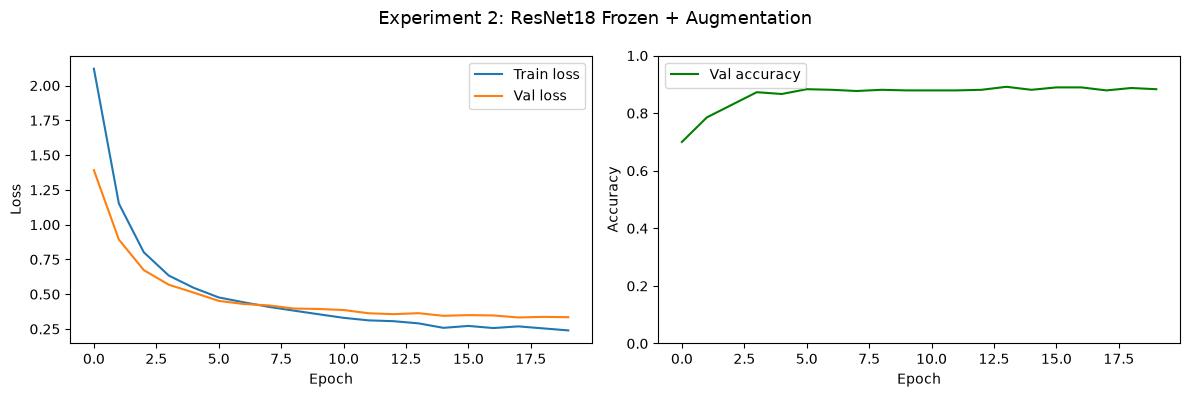

Best val accuracy: 0.8917 (89.2%)

Per-class accuracy (val set):
Class                     Acc  Bar
----------------------------------------------------
Bedroom                69.2%  █████████████
OpenCountry            71.4%  ██████████████
InsideCity             80.0%  ████████████████
Store                  83.9%  ████████████████
Coast                  84.8%  ████████████████
Mountain               89.3%  █████████████████
Industrial             89.7%  █████████████████
Kitchen                90.0%  ██████████████████
LivingRoom             92.3%  ██████████████████
Street                 93.8%  ██████████████████
Office                 95.8%  ███████████████████
Highway                96.4%  ███████████████████
Suburb                 97.1%  ███████████████████
Flower                 100.0%  ████████████████████
Forest                 100.0%  ████████████████████
TallBuilding           100.0%  ████████████████████

Mean: 89.6%  |  Min: 69.2%  |  Max: 100.0%


array([0.6923077 , 0.8484849 , 1.        , 1.        , 0.96428573,
       0.8965517 , 0.8       , 0.9       , 0.9230769 , 0.89285713,
       0.9583333 , 0.71428573, 0.83870965, 0.9375    , 0.9705882 ,
       1.        ], dtype=float32)

In [15]:
plot_history(history_exp2, label='Experiment 2: ResNet18 Frozen + Augmentation', save_path='plots/exp2_resnet18_aug.png')
per_class_accuracy(resnet2, exp1_val_loader, class_names, device)

---

## Experiment 3: ResNet18 Frozen + Cosine LR Scheduling

**Hypothesis:** The flat learning rate in Exp 1 caused mild oscillation near the optimum (best checkpoint was at epoch ~13, final was lower). A cosine decay schedule that smoothly reduces LR to near zero should converge to a better final checkpoint and reduce late-epoch regression.

**Change from Exp 1:** Added `CosineAnnealingLR(T_max=20)` — no augmentation, identical to Exp 1 otherwise. Isolates the scheduler's contribution.

**Why cosine over step decay or ReduceLROnPlateau:**
- Step decay is abrupt and requires tuning when to step
- ReduceLROnPlateau reacts to val loss — useful but adds variance
- Cosine is smooth, parameter-free given epochs, and is the standard modern default

**Requires:** Exp 1 setup cell (`weights`, `resnet_transform`, `exp1_val_loader`, `exp1_train_loader`, etc.)

In [32]:
# Fresh frozen ResNet18 — identical to Exp 1, only adds cosine LR schedule
set_random_seed(SEED)
resnet3 = resnet18(weights=ResNet18_Weights.DEFAULT)
for param in resnet3.parameters():
    param.requires_grad = False
resnet3.fc = nn.Linear(resnet3.fc.in_features, num_classes)

optimizer_exp3 = optim.Adam(resnet3.fc.parameters(), lr=1e-3)
scheduler_exp3 = optim.lr_scheduler.CosineAnnealingLR(optimizer_exp3, T_max=20)

resnet3, history_exp3 = train_model(
    resnet3, exp1_train_loader, exp1_val_loader,
    optimizer_exp3, epochs=20, device=device, scheduler=scheduler_exp3
)

Epochs:   0%|          | 0/20 [00:00<?, ?epoch/s]

  Epoch 01:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 02:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 03:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 04:   0%|          | 0/30 [00:00<?, ?batch/s]

...

  Epoch 06:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 07:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 08:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 09:   0%|          | 0/30 [00:00<?, ?batch/s]

KeyboardInterrupt: 

Saved to plots/exp3_resnet18_cosine.png


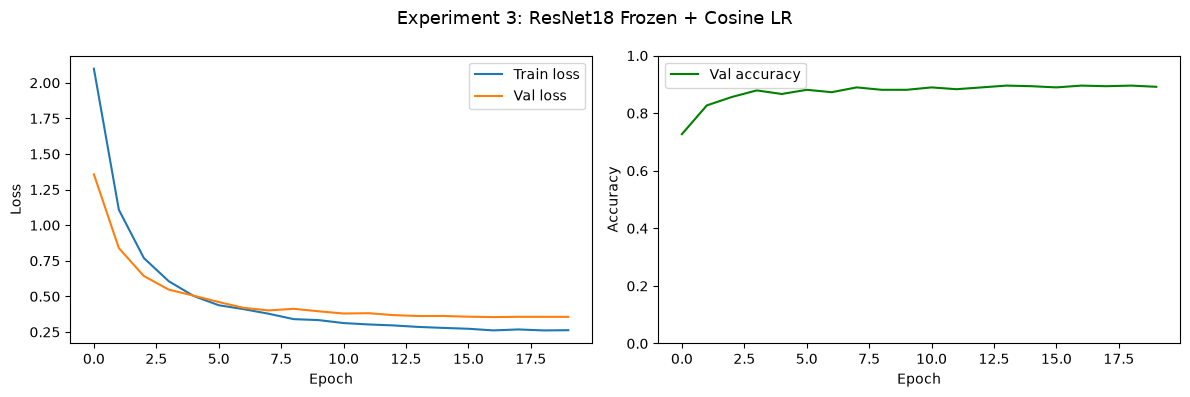

Best val accuracy: 0.8958 (89.6%)

Per-class accuracy (val set):
Class                     Acc  Bar
----------------------------------------------------
OpenCountry            75.0%  ███████████████
LivingRoom             80.8%  ████████████████
Coast                  81.8%  ████████████████
Bedroom                82.1%  ████████████████
InsideCity             83.3%  ████████████████
Store                  87.1%  █████████████████
Industrial             89.7%  █████████████████
Kitchen                90.0%  ██████████████████
Street                 90.6%  ██████████████████
Highway                92.9%  ██████████████████
Mountain               92.9%  ██████████████████
Office                 95.8%  ███████████████████
Forest                 96.6%  ███████████████████
Suburb                 97.1%  ███████████████████
Flower                 100.0%  ████████████████████
TallBuilding           100.0%  ████████████████████

Mean: 89.7%  |  Min: 75.0%  |  Max: 100.0%


array([0.82051283, 0.8181818 , 1.        , 0.9655172 , 0.9285714 ,
       0.8965517 , 0.8333333 , 0.9       , 0.8076923 , 0.9285714 ,
       0.9583333 , 0.75      , 0.87096775, 0.90625   , 0.9705882 ,
       1.        ], dtype=float32)

In [19]:
plot_history(history_exp3, label='Experiment 3: ResNet18 Frozen + Cosine LR', save_path='plots/exp3_resnet18_cosine.png')
per_class_accuracy(resnet3, exp1_val_loader, class_names, device)

---

## Experiment 4: ResNet18 Partial Fine-Tune (layer4 + head)

**Hypothesis:** Unfreezing layer4 lets the highest-level features adapt toward scene discrimination. With the backbone now able to respond to augmented views and a more complex loss landscape, augmentation and cosine scheduling should help rather than hurt.

**Changes from Exp 1:**
- Layers 1–3 frozen, layer4 + head trainable (~2.6M / 11M params)
- lr=1e-4 for all trainable params — small enough to protect pretrained weights from catastrophic forgetting
- Augmented train transform (same as Exp 2)
- CosineAnnealingLR over 30 epochs
- 30 epochs — fine-tuning converges more slowly than linear probing

In [33]:
set_random_seed(SEED)
resnet4 = resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze everything first, then selectively unfreeze layer4
for param in resnet4.parameters():
    param.requires_grad = False

for param in resnet4.layer4.parameters():
    param.requires_grad = True

# Replace head — trainable by default (new nn.Linear has requires_grad=True)
resnet4.fc = nn.Linear(resnet4.fc.in_features, num_classes)

trainable = sum(p.numel() for p in resnet4.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet4.parameters())
print(f"Trainable: {trainable:,} / {total:,} parameters ({trainable/total*100:.1f}%)")
print("Trainable layers: layer4 + fc  |  Frozen: layer1, layer2, layer3, conv1, bn1")

# Single small LR for all trainable params — protects pretrained layer4 weights
optimizer_exp4  = optim.Adam(
    filter(lambda p: p.requires_grad, resnet4.parameters()), lr=1e-4
)
scheduler_exp4 = optim.lr_scheduler.CosineAnnealingLR(optimizer_exp4, T_max=30)

# Augmented train loader from Exp 2, clean val loader from Exp 1
resnet4, history_exp4 = train_model(
    resnet4, exp2_train_loader, exp1_val_loader,
    optimizer_exp4, epochs=30, device=device, scheduler=scheduler_exp4
)

Trainable: 8,401,936 / 11,184,720 parameters (75.1%)
Trainable layers: layer4 + fc  |  Frozen: layer1, layer2, layer3, conv1, bn1


Epochs:   0%|          | 0/30 [00:00<?, ?epoch/s]

  Epoch 01:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 02:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 03:   0%|          | 0/30 [00:00<?, ?batch/s]

...

  Epoch 27:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 28:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 29:   0%|          | 0/30 [00:00<?, ?batch/s]

  Epoch 30:   0%|          | 0/30 [00:00<?, ?batch/s]

Training complete in 979.0s | Best val accuracy: 0.9437


Saved to plots/exp4_resnet18_partial_finetune.png


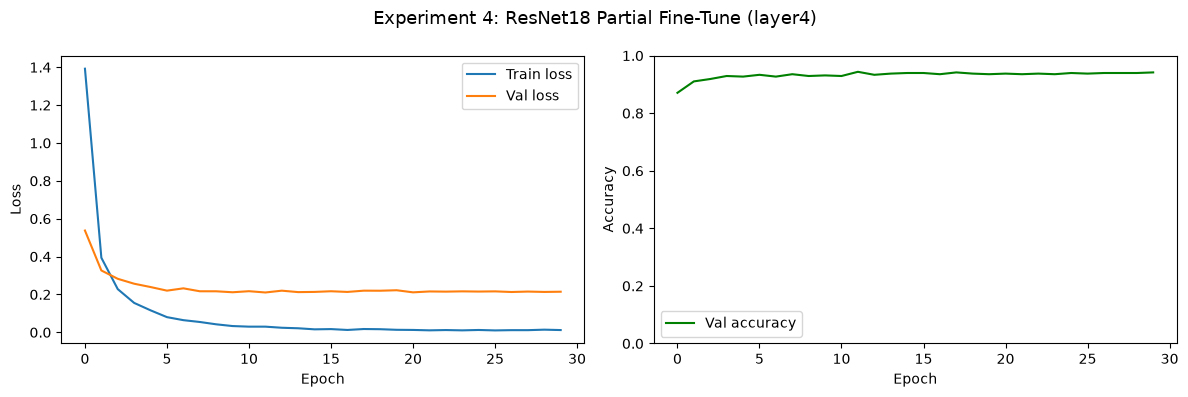

Best val accuracy: 0.9437 (94.4%)

Per-class accuracy (val set):
Class                     Acc  Bar
----------------------------------------------------
OpenCountry            85.7%  █████████████████
Bedroom                87.2%  █████████████████
LivingRoom             88.5%  █████████████████
Industrial             89.7%  █████████████████
InsideCity             90.0%  ██████████████████
Store                  90.3%  ██████████████████
Kitchen                93.3%  ██████████████████
Highway                96.4%  ███████████████████
Mountain               96.4%  ███████████████████
Coast                  97.0%  ███████████████████
Suburb                 97.1%  ███████████████████
Flower                 100.0%  ████████████████████
Forest                 100.0%  ████████████████████
Office                 100.0%  ████████████████████
Street                 100.0%  ████████████████████
TallBuilding           100.0%  ████████████████████

Mean: 94.5%  |  Min: 85.7%  |  Max: 100.0%


array([0.8717949 , 0.969697  , 1.        , 1.        , 0.96428573,
       0.8965517 , 0.9       , 0.93333334, 0.88461536, 0.96428573,
       1.        , 0.85714287, 0.9032258 , 1.        , 0.9705882 ,
       1.        ], dtype=float32)

In [34]:
plot_history(history_exp4, label='Experiment 4: ResNet18 Partial Fine-Tune (layer4)', save_path='plots/exp4_resnet18_partial_finetune.png')
per_class_accuracy(resnet4, exp1_val_loader, class_names, device)

## 6. Your turn: beat the baseline

This simple model should only be treated as a sanity check. Your objective is to substantially improve it.

Rather than asking an AI tool to ``make the accuracy higher,'' formulate hypotheses yourself. Examples of useful questions include whether the model is overfitting, whether color matters, whether stronger augmentation helps, whether a different CNN family is more appropriate, whether pretrained CNN features transfer well, or whether optimization/regularization is limiting performance.

For each important experiment, write down:

| Experiment | What changed? | Why did you try it? | Validation accuracy | What did you learn? |
|---|---|---|---:|---|
| Baseline | Starter TNet | Sanity check | -- | -- |
| Experiment 1 | | | | |
| Experiment 2 | | | | |
| Final model | | | | |

**Do not use the test set to choose among these experiments.**

In [ ]:
# FINAL TEST EVALUATION
# Run this only after you have selected your final model using validation results.
# Replace `model` with your final selected model/checkpoint.

test_loss, test_acc = evaluate(model, test_loader, device)
print(f'Final test loss: {test_loss:.4f}')
print(f'Final test accuracy: {test_acc:.4f}')

## 7. AI-assisted development checkpoint

Before submission, create `AI_USAGE.md` in your GitHub repository. You do **not** need to provide every prompt. Include:

1. the AI coding tool(s) you used;
2. 3--5 representative ways AI assisted you;
3. at least one AI suggestion that was incorrect, ineffective, or questionable;
4. how you tested, verified, corrected, or rejected that suggestion; and
5. one important architecture/experimental decision that **you** made.

A good entry describes the engineering/research interaction rather than saying only, ``I used ChatGPT to write code.''

### A useful habit
When AI generates code, ask yourself before running it:
- What do I expect this code to do?
- What assumption is it making about tensor shape/data/model behavior?
- How will I know if it is wrong?
- What experiment would distinguish a real improvement from noise?

## 8. GitHub and submission requirements

All assignment code must be maintained in **GitHub** (not GitLab). Your repository should contain a meaningful commit history and, at minimum:

```text
README.md
AI_USAGE.md
training / model code
inference or evaluation code
requirements.txt or environment information
final checkpoint or a link to it
reproduction instructions
```

Do not create the entire repository as a single commit immediately before the deadline. Use Git throughout development as you would in a real research or engineering project.

Your final submission is a **maximum two-page PDF report** containing the working GitHub link. The report should clearly state your best result, validation/model-selection strategy, final recipe, important experiments, at least one failure analysis, and a brief AI+human reflection.

Friendly discussion and brainstorming are encouraged, but your implementation, experiments, report, and repository must be your own. Do not share code, checkpoints, detailed hyperparameters, or test predictions before the deadline.

The instructor may ask you to explain any important component of your submitted system. You are responsible for understanding all code in your final repository, including AI-generated code.

**Deadline: September 25, 2026 at 11:59 PM EDT.**

Good luck — and treat this as your first small computer vision research project of the semester.